In [1]:
import matplotlib.pyplot as plt
import matplotlib
from functools import partial
import numpy as np
import pickle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from shapely.geometry import LineString  # purely geometric intersection

'''
col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}
'''

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})

x = np.arange(1,7300)
y = np.arange(1,30)
N_grid, T_grid = np.meshgrid(x, y)
T0 = 5
N0 = 64 

/tmp/ipykernel_5739/2517666609.py:138: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = axsmaps[0,1].contour(Texe_grid,
/tmp/ipykernel_5739/2517666609.py:170: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = axsmaps[0,0].contour(peak_mem_grid / RAM * 100,
/tmp/ipykernel_5739/2517666609.py:179: UserWarning: linewidths is ignored by contourf
  cset1 = axsmaps[0,2].contourf(peak_mem_grid / RAM * 100, levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_5739/2517666609.py:179: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cset1 = axsmaps[0,2].contourf(peak_mem_grid / RAM * 100, levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_5739/2517666609.py:222: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = axsmaps[1,t].contour(Ttot_grid,
/tmp/ipykernel_5739/25176

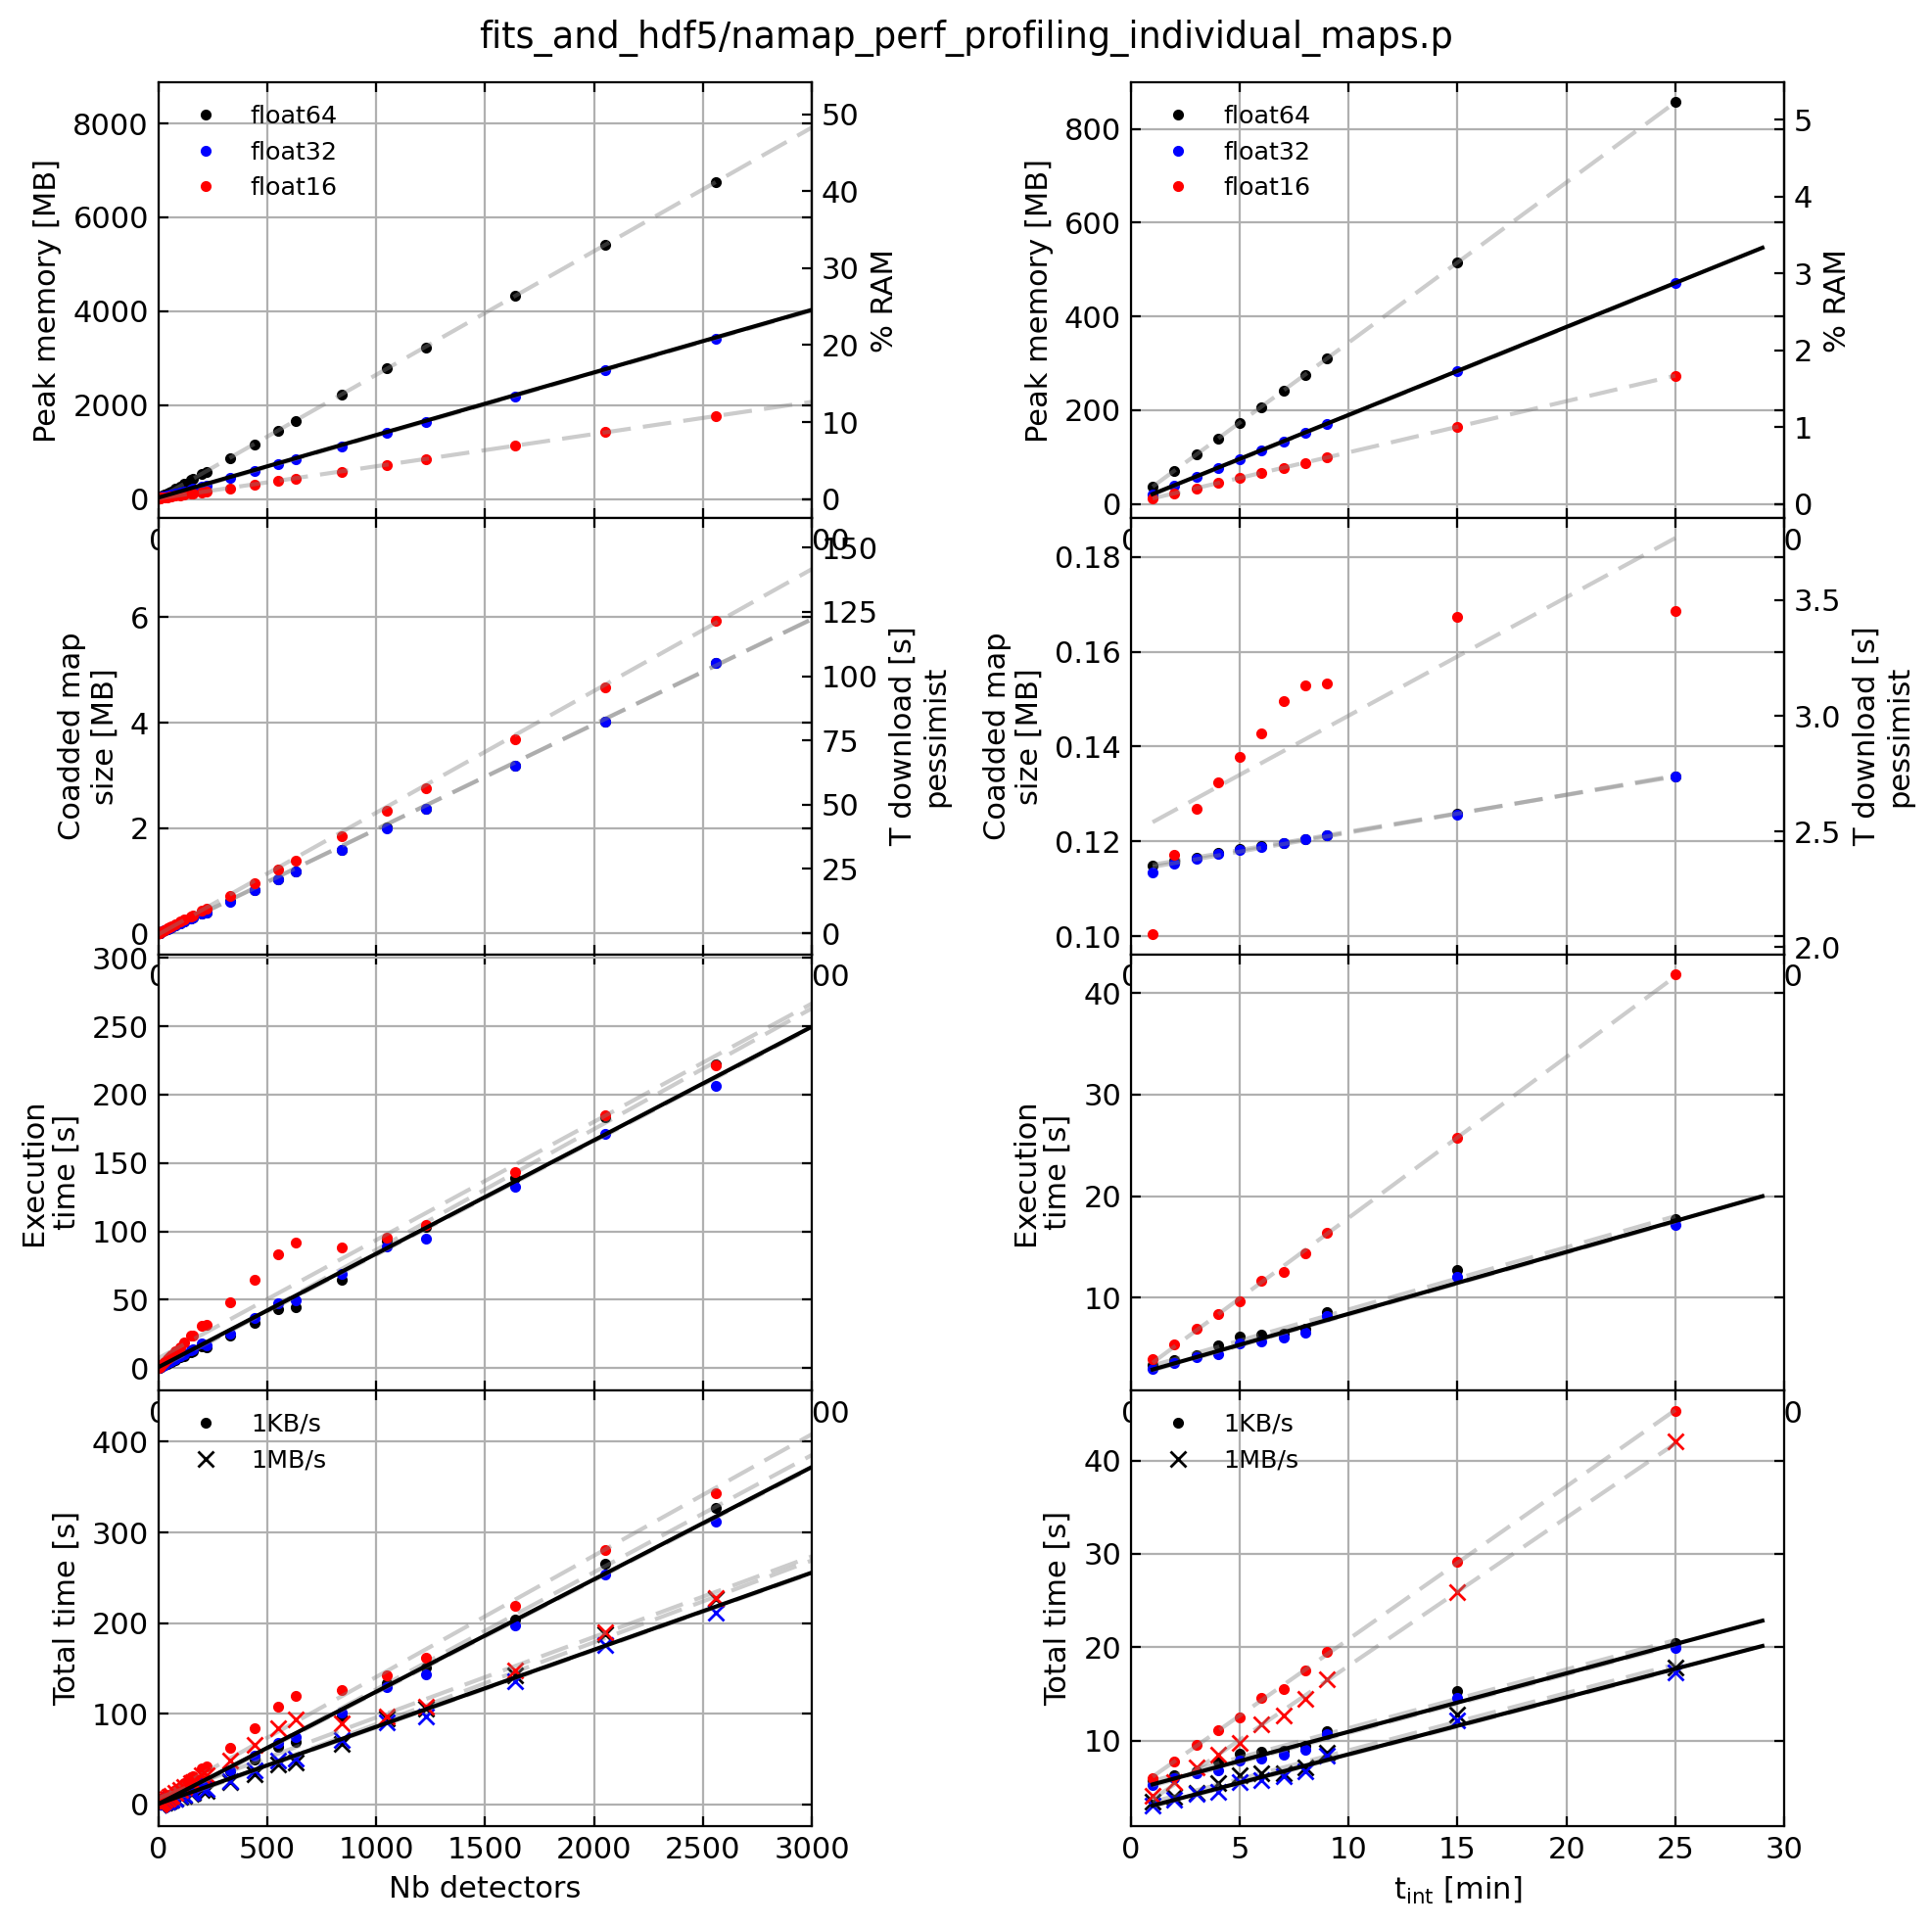

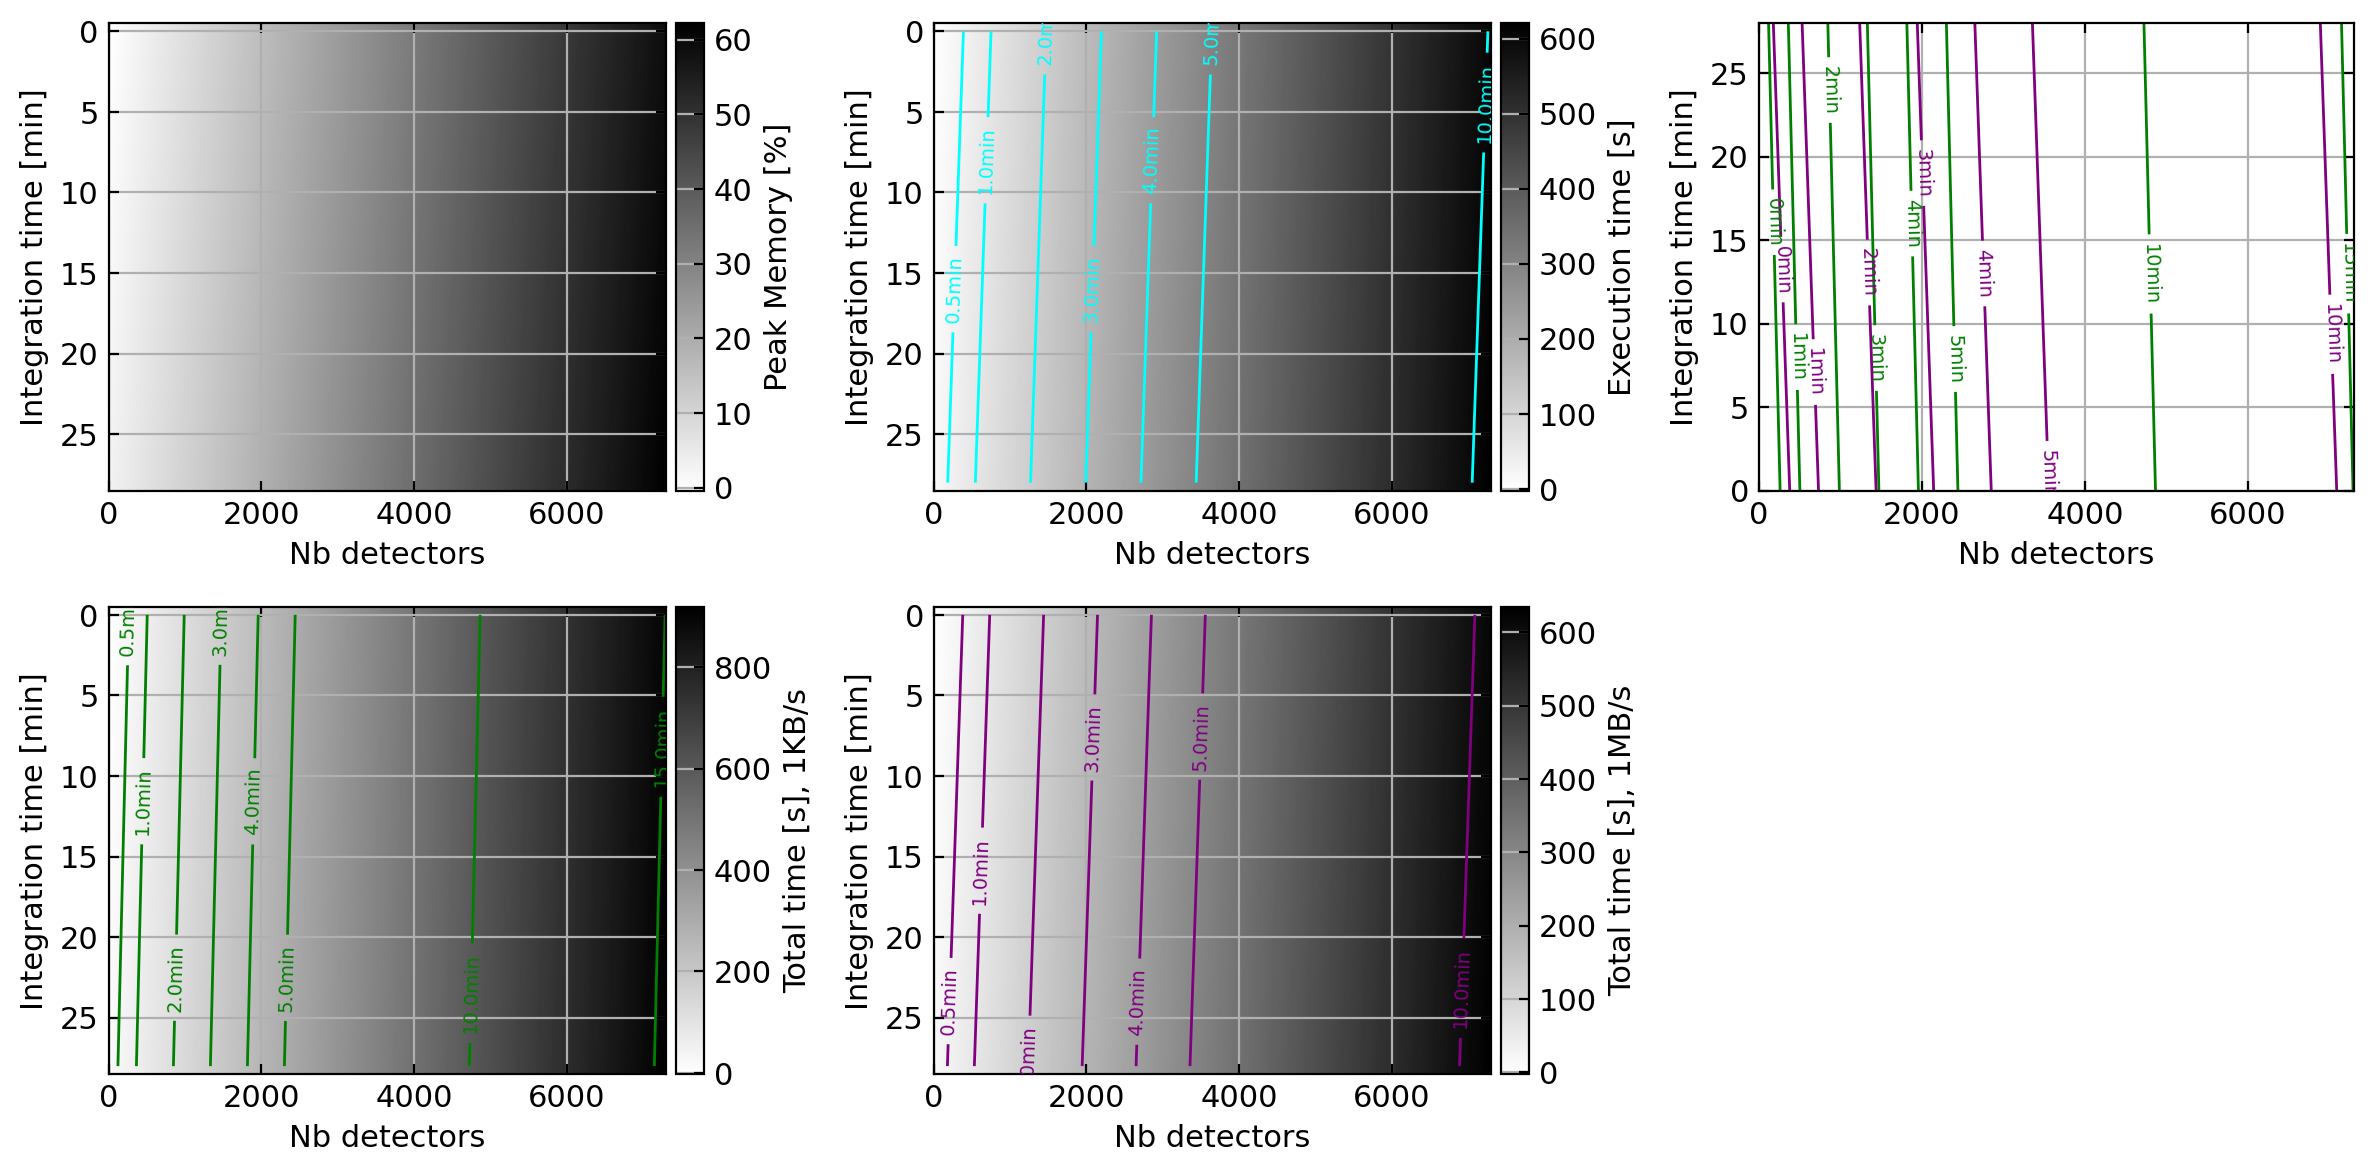

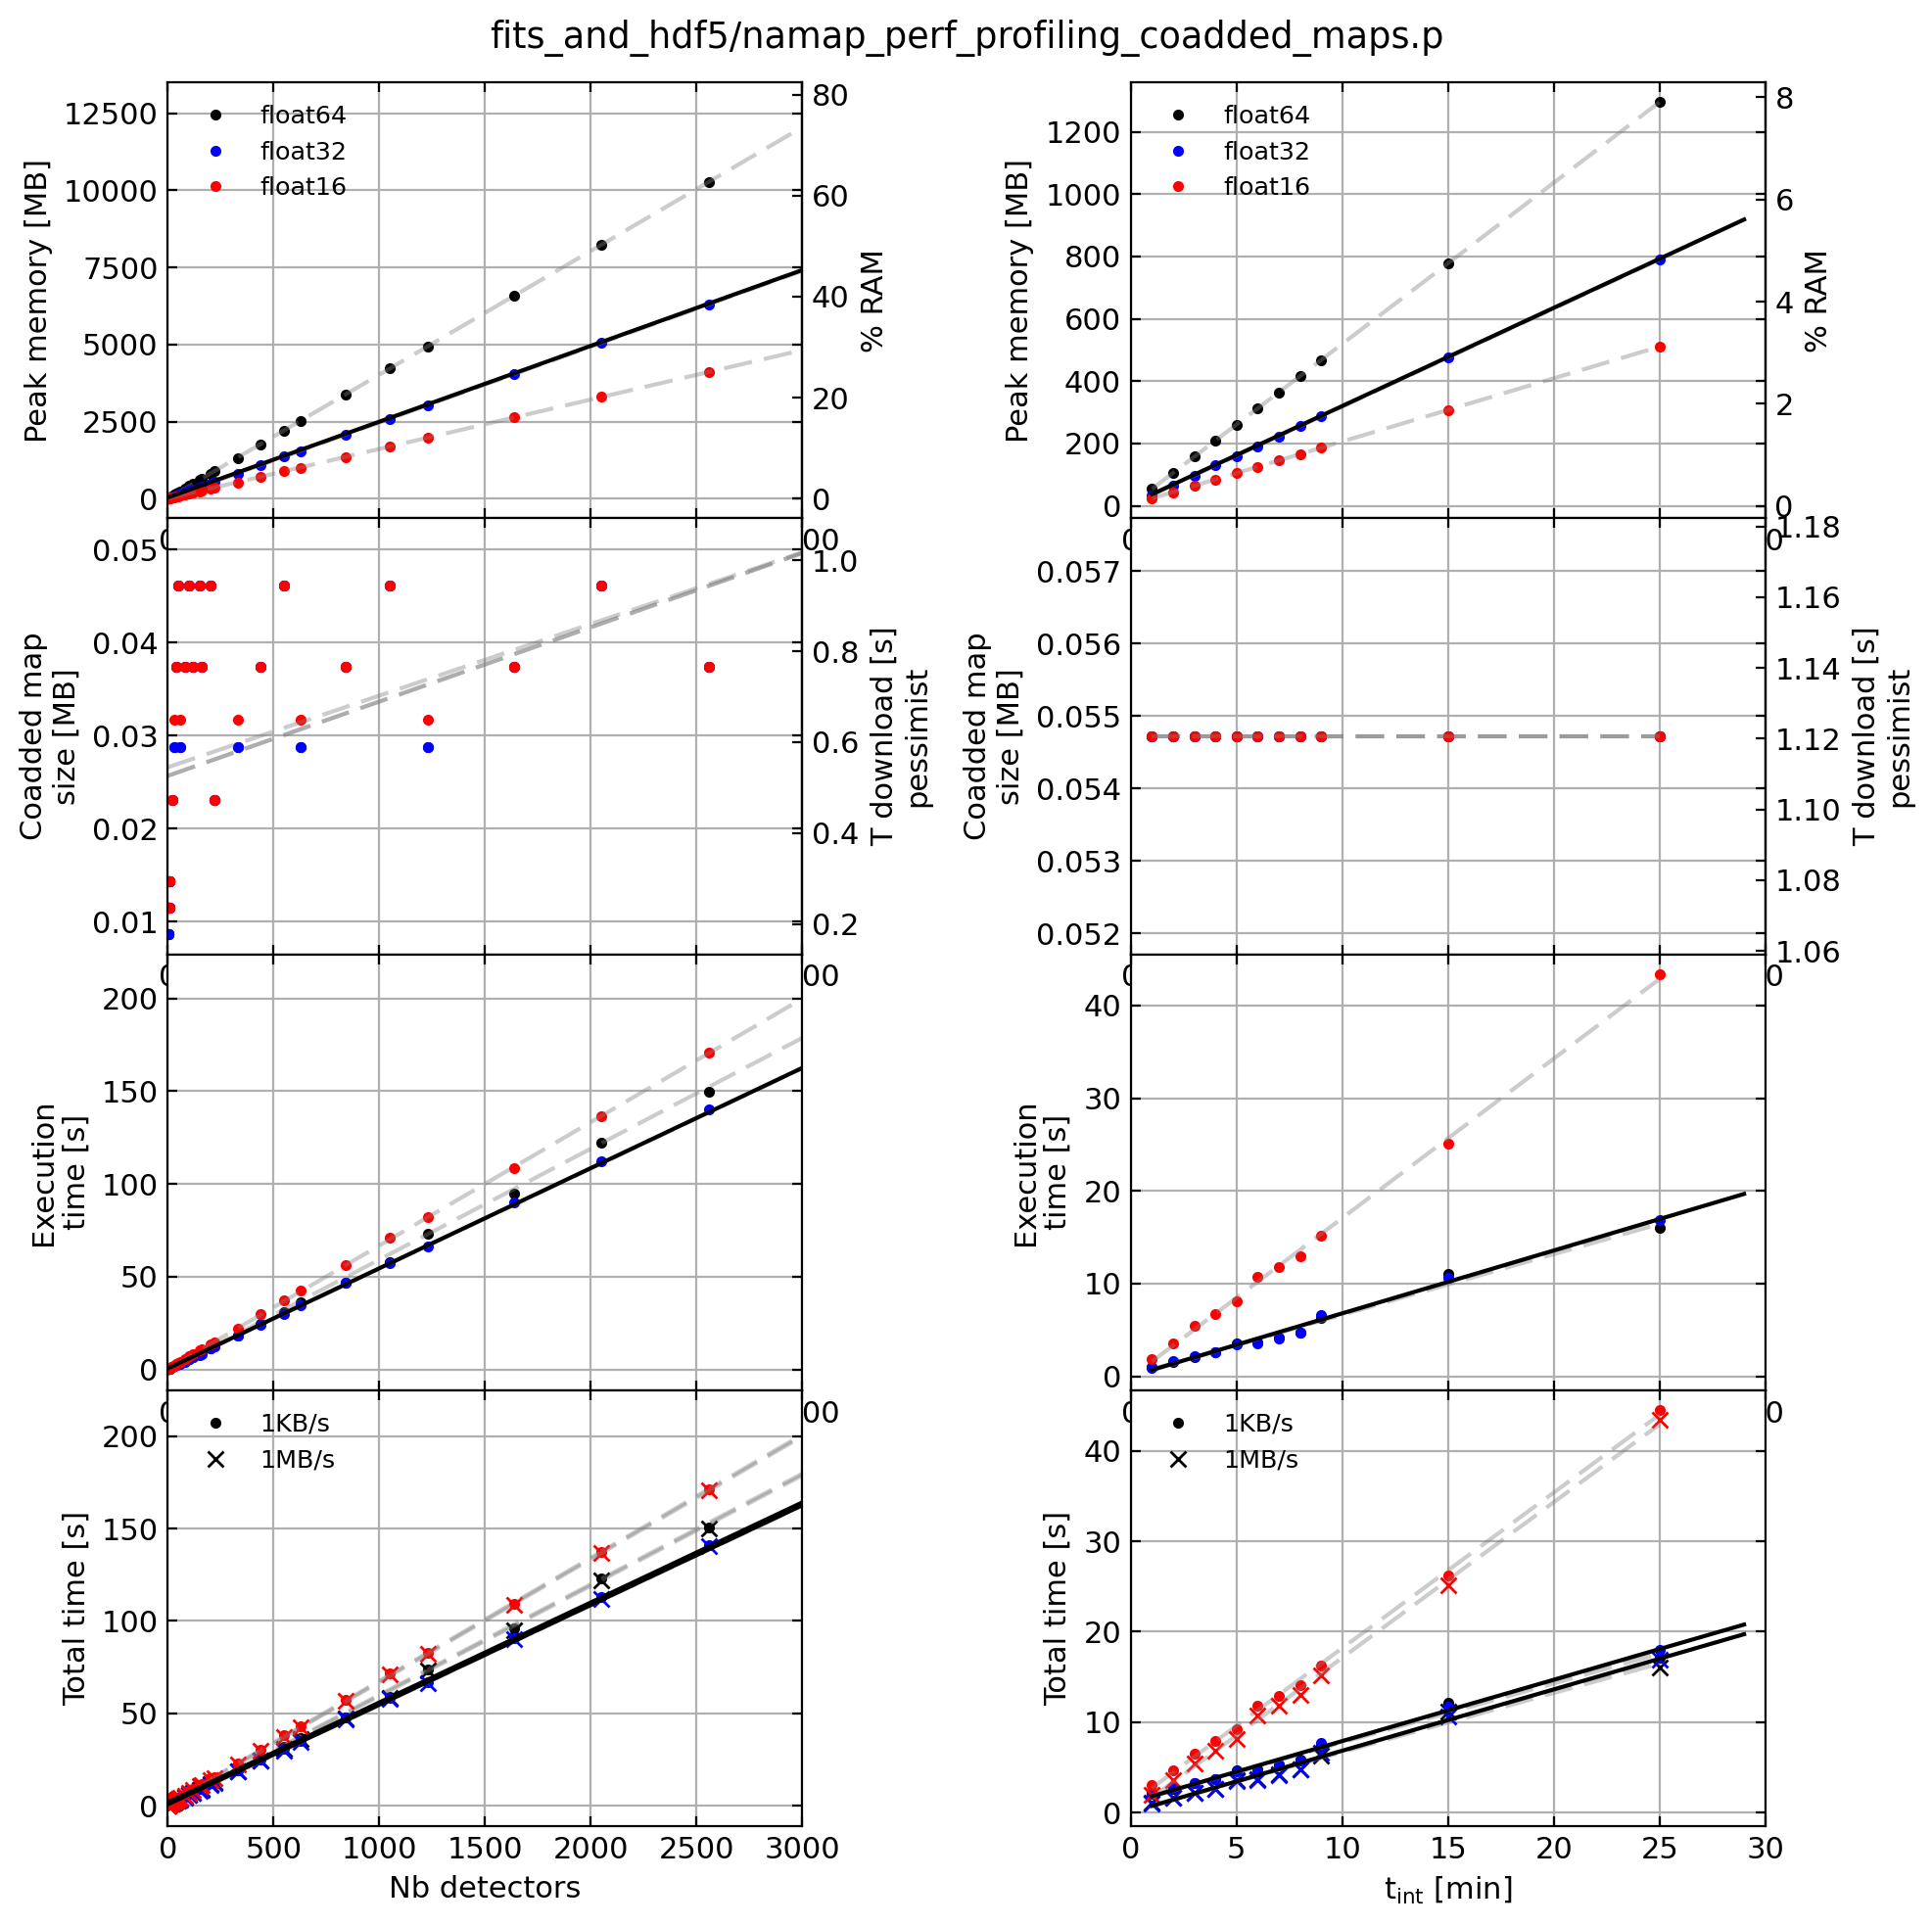

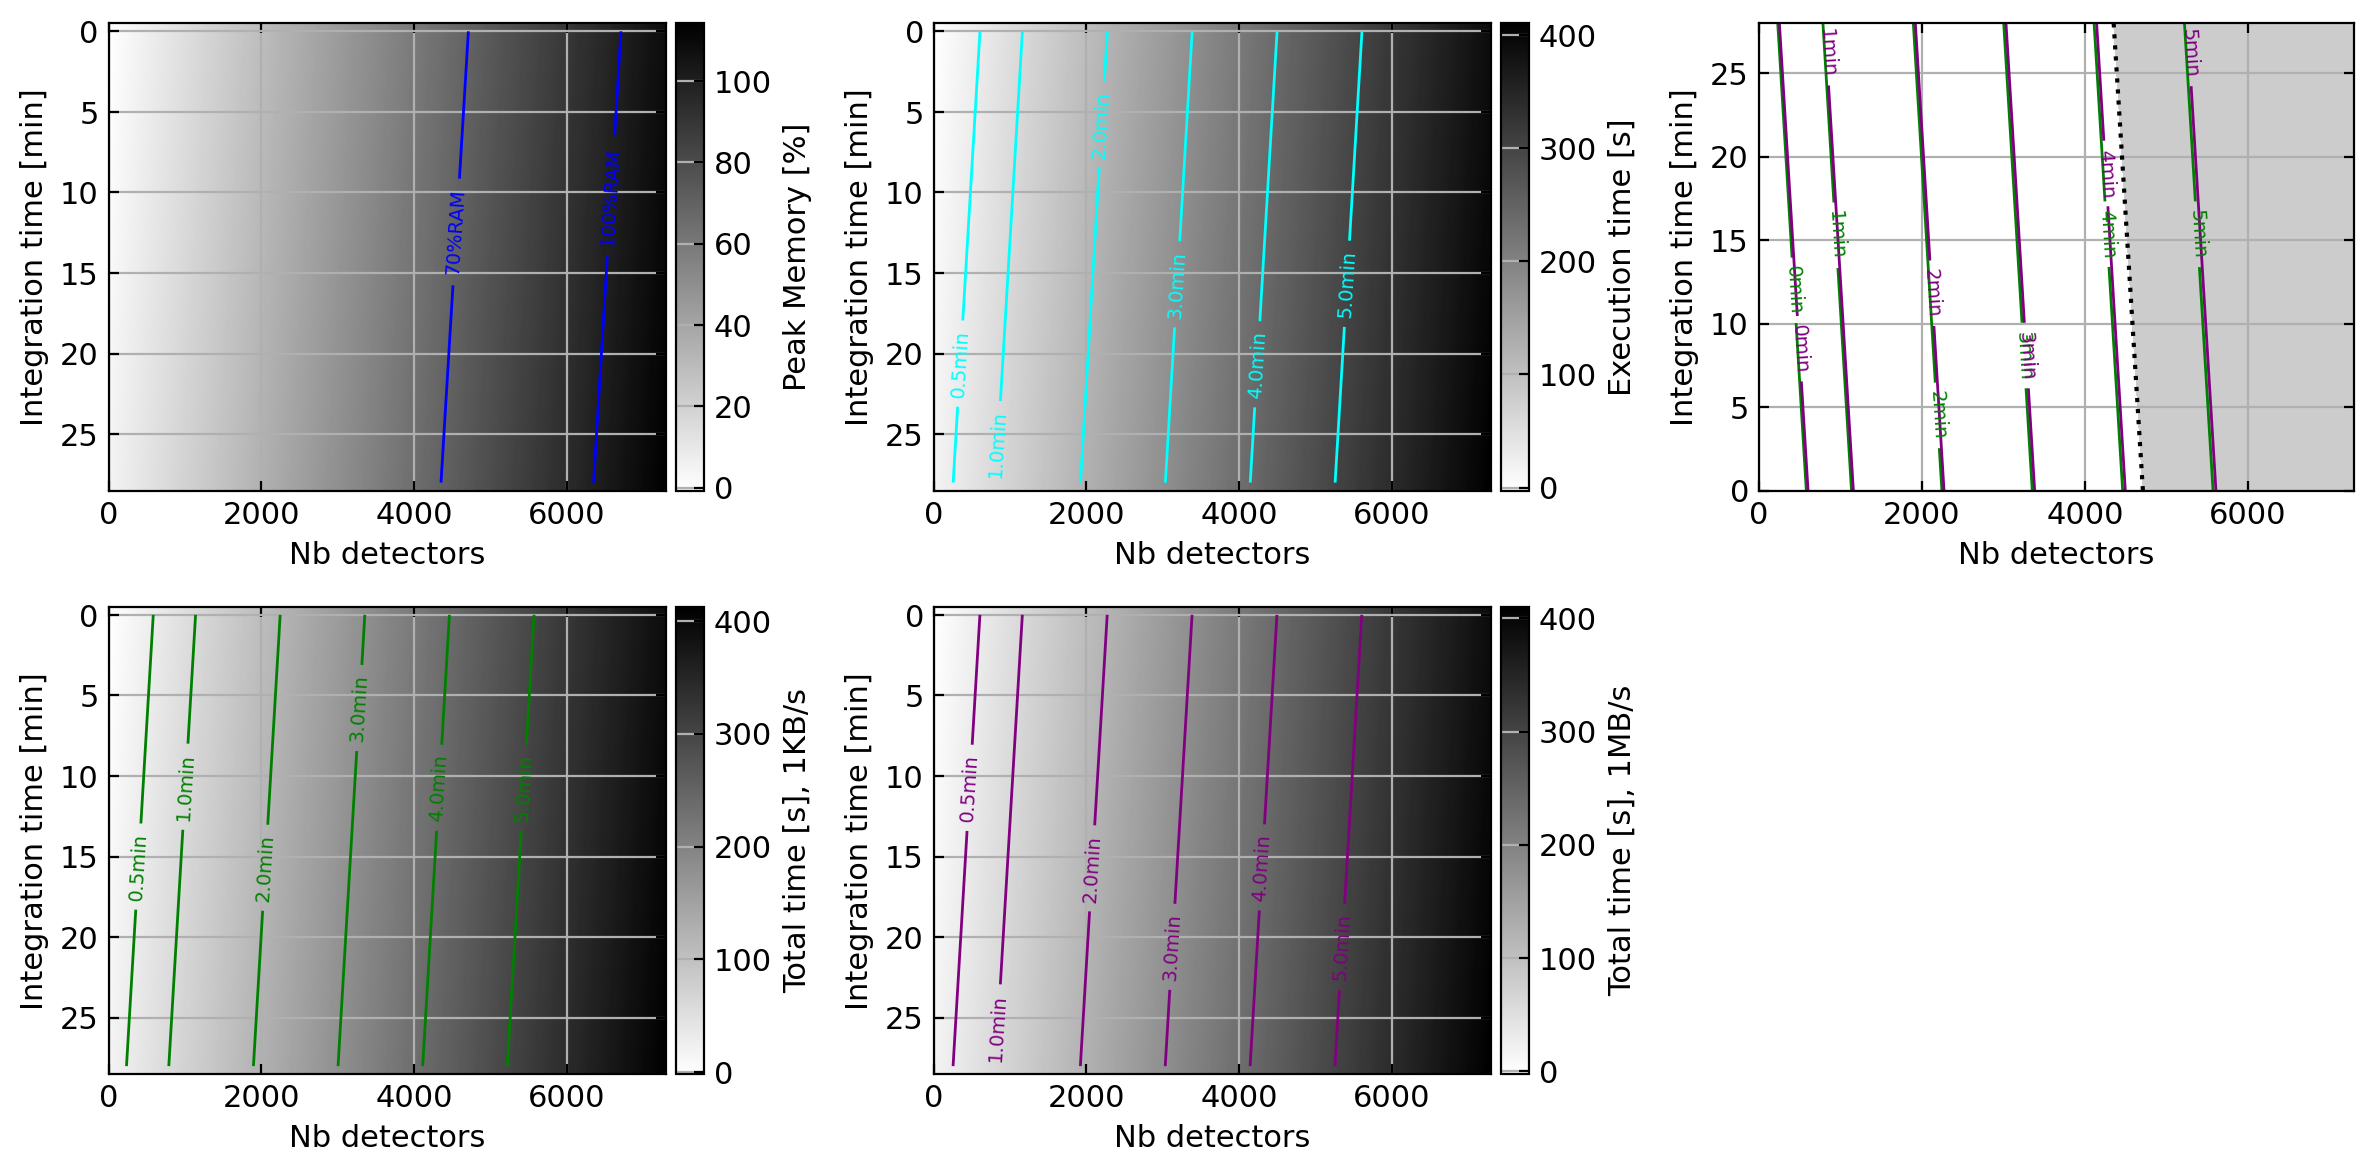

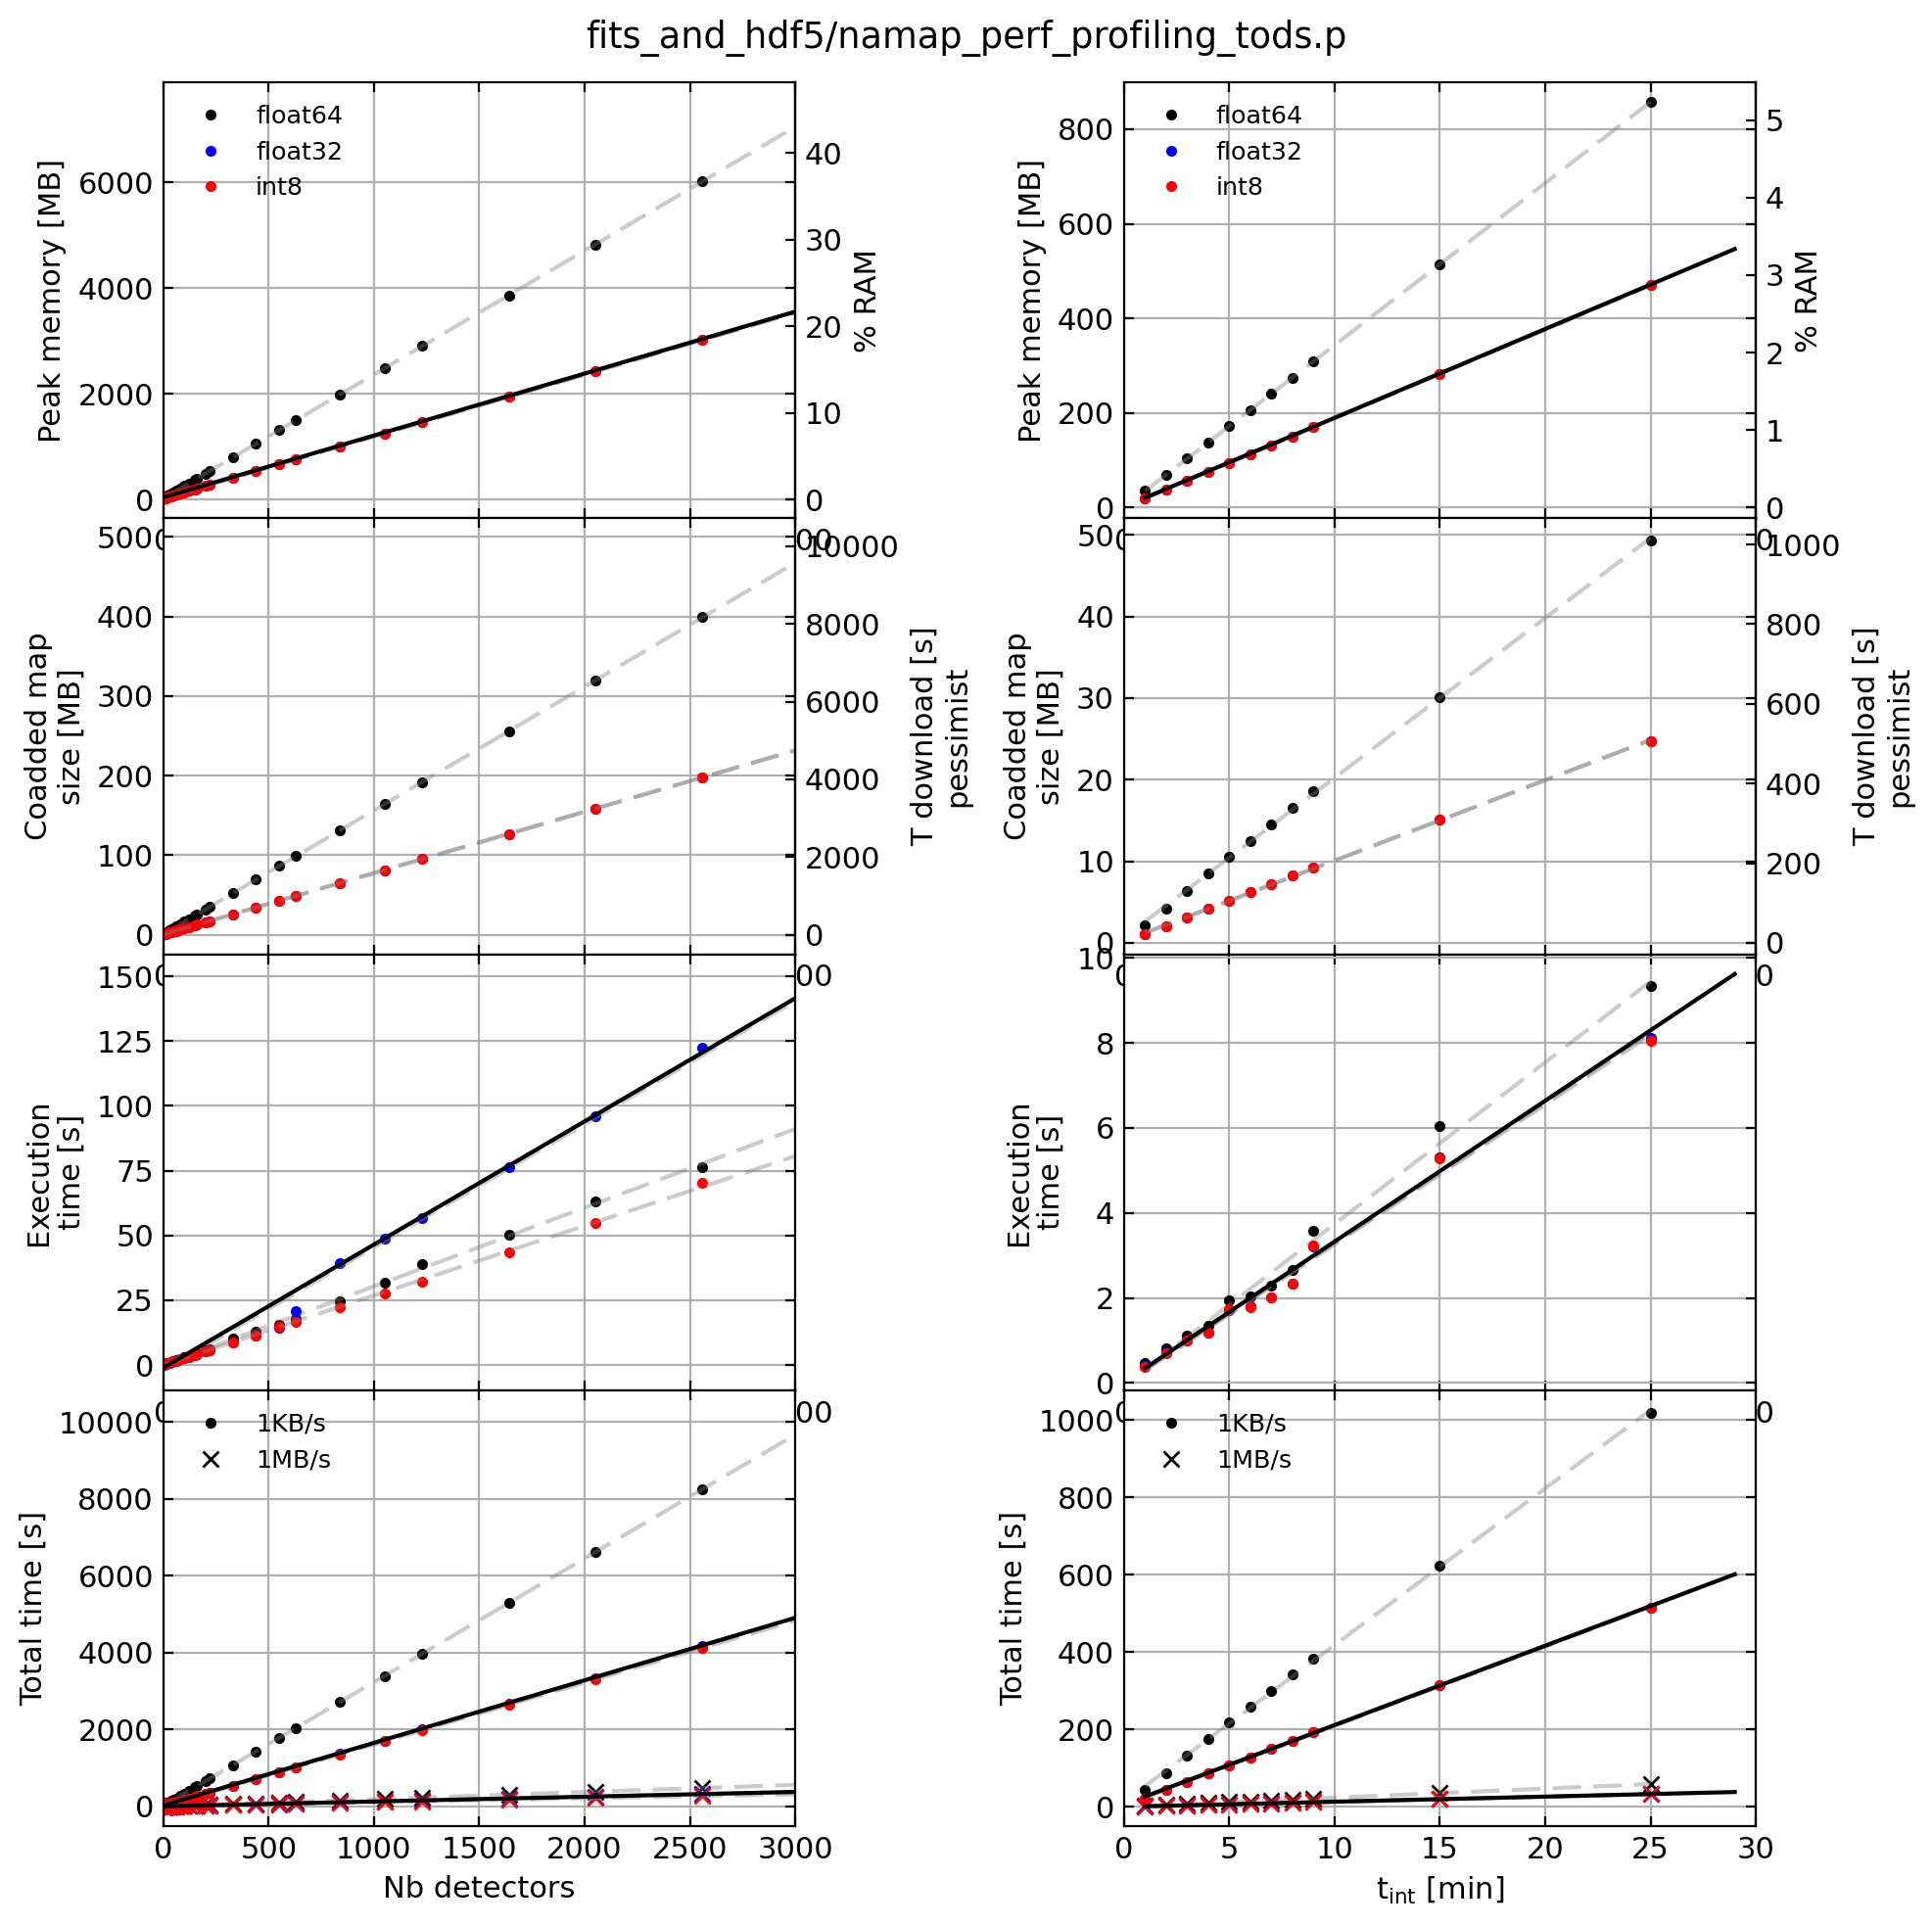

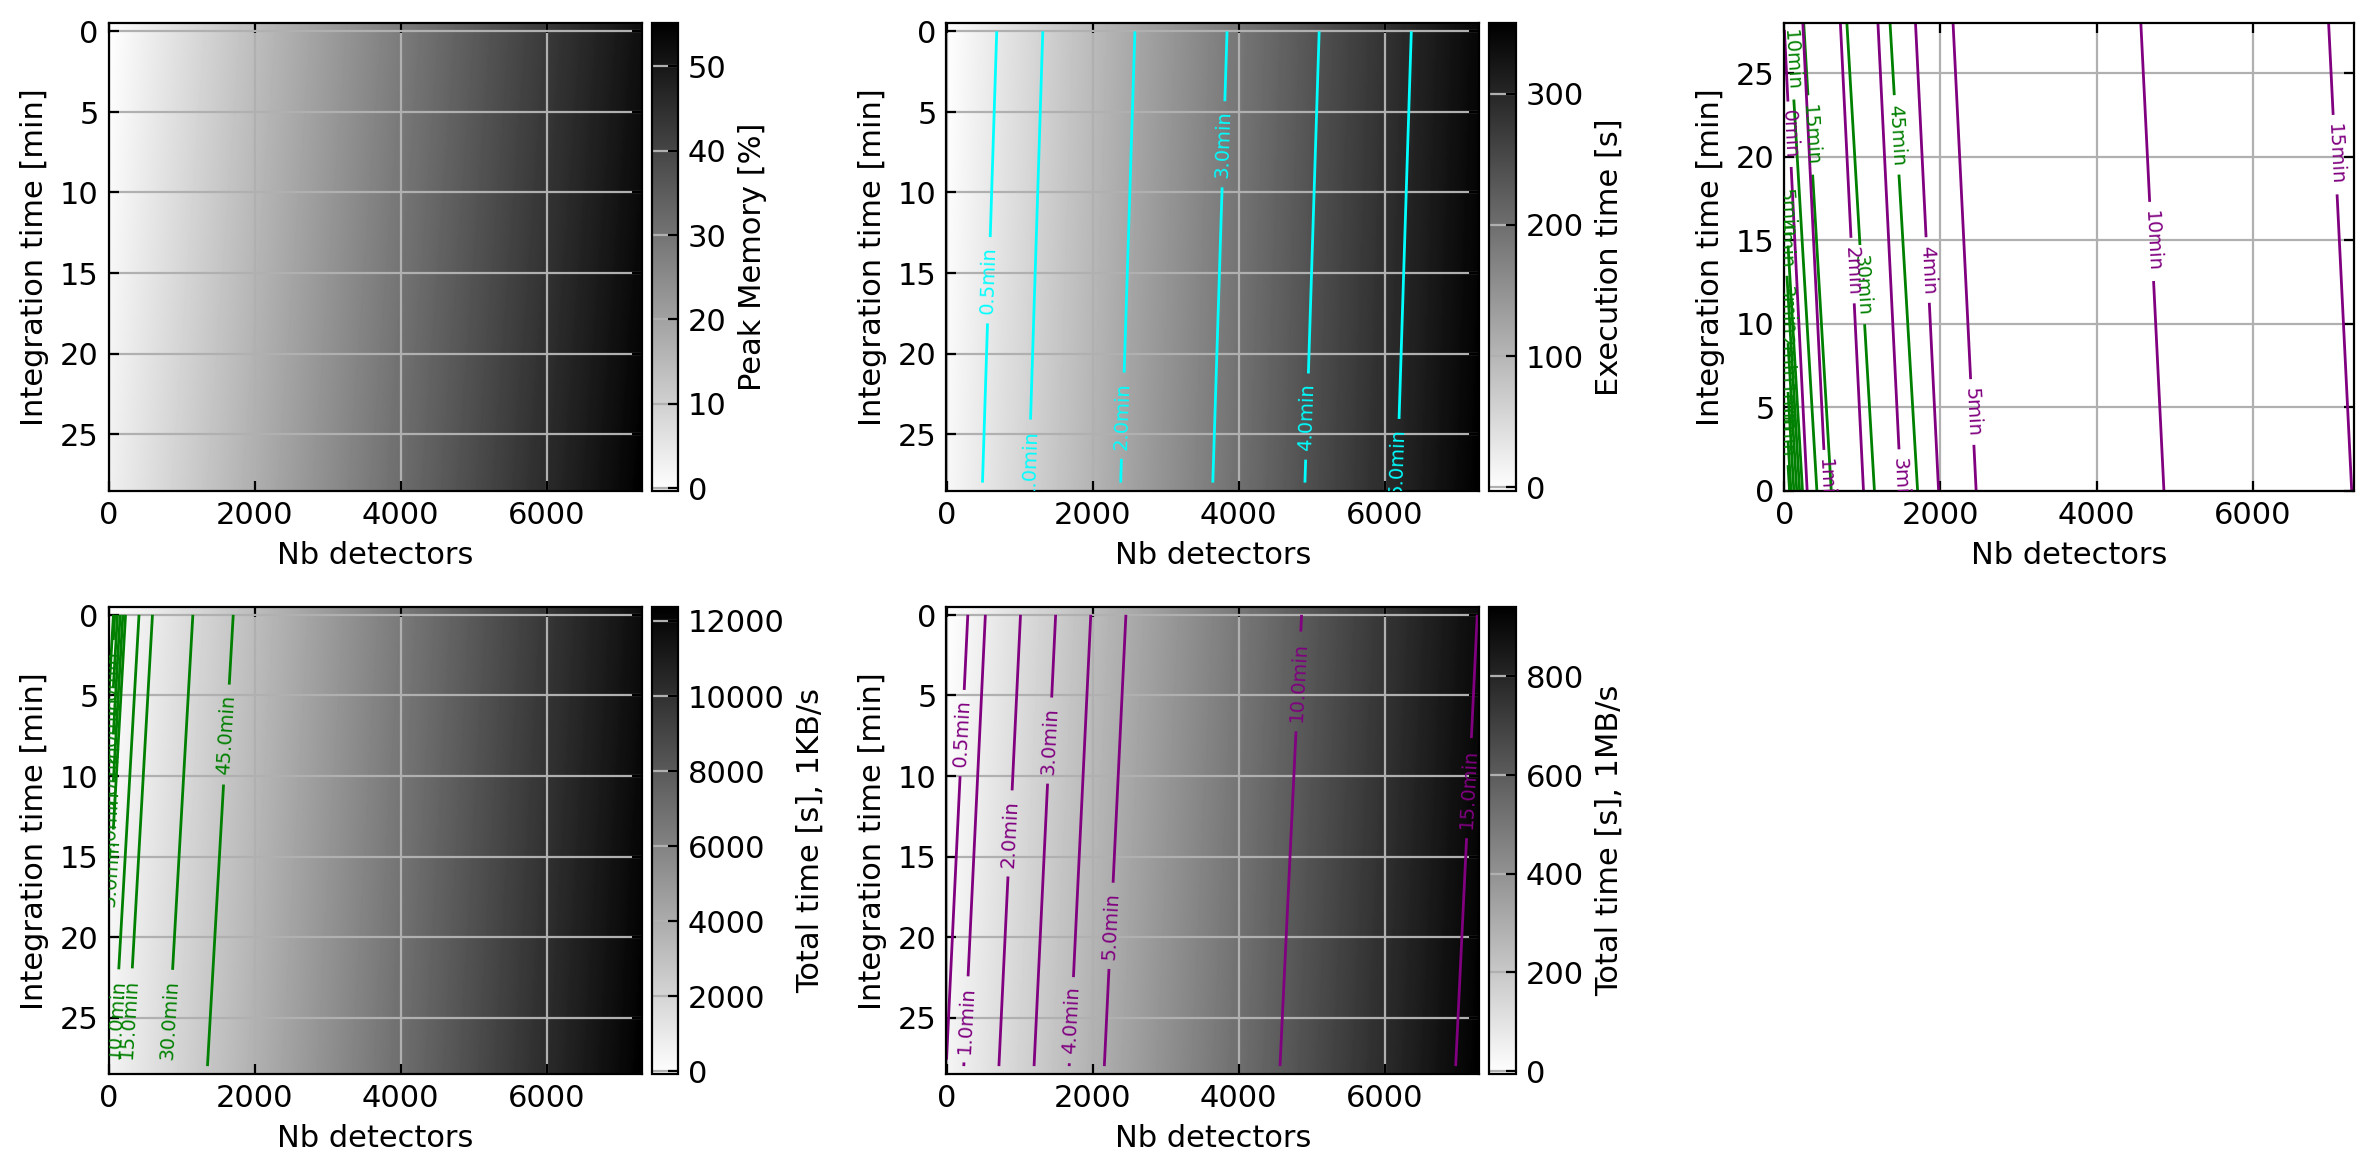

In [2]:
files = ('fits_and_hdf5/namap_perf_profiling_individual_maps.p', 'fits_and_hdf5/namap_perf_profiling_coadded_maps.p','fits_and_hdf5/namap_perf_profiling_tods.p' ) #
compressions = ('individual.fits.gz', 'coadd.fits', 'tods.hdf5')

for file, map_compression in zip(files, compressions):
    perfs = pickle.load( open(file, 'rb'))
    fig, axs = plt.subplots(4,2,figsize=(10,10), dpi=200)
    figmaps, axsmaps = plt.subplots(2,3,figsize=(12,6), dpi=200)

    list_linear_params_ram = np.zeros((2,3,2)) #band ttot texe, precision, a and b
    list_linear_params_texe = np.zeros((2,3,2)) #band ttot texe, precision, a and b
    list_linear_params_ttot = np.zeros((2,3,2,2)) #band ttot texe, precision, a and b

    for i, (key, key2) in enumerate(zip(('profiling vs nb bands','profiling vs tod time'),( "nb dets","t_int")) ):#

        axm, axb, axt, axT = axs[0,i], axs[1,i], axs[2,i],axs[3,i]


        for l1 in range(2):
            for l2 in range(3):
                axsmaps[l1,l2].set_ylabel("Integration time [min]")
                axsmaps[l1,l2].set_xlabel("Nb detectors")


        axs[3,0].set_xlabel("Nb detectors")
        axs[3,1].set_xlabel("Integration time [min]")

        if('det' in key2): lim=3000
        else: lim=30
    
        axm.set_xlim(0,lim)
        axb.set_xlim(0,lim)
        axt.set_xlim(0,lim)
        axT.set_xlim(0,lim)

        axm.set_ylabel('Peak memory [MB]')
        axt.set_ylabel('Execution\ntime [s]')
        axT.set_ylabel('Total time [s]')
        #axm.set_title("488Hz, 40'', 64detectors")
        axt.set_xlabel("$\\rm t_{int}$ [min]")
        axT.set_xlabel("$\\rm t_{int}$ [min]")
        axb.set_ylabel('Coadded map\nsize [MB]')
        fig.suptitle(file)
        axb.set_ylabel('Coadded map\nsize [MB]')
        axT.set_ylabel('Total time [s]')

        for p, (precision, color) in enumerate(zip(('float64', 'float32', 'float16'),('k','b','r'))): 
            if('16' in precision and 'tods' in map_compression): precision = 'int8'
            #-----------------------------------------------------------------------------------------------------------------------
            axm.plot(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], f'.{color}', label= precision)
            a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], 1)
            list_linear_params_ram[i,p,0], list_linear_params_ram[i,p,1] = a_coeffs
            p_lin = np.poly1d(a_coeffs)
            x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
            y_lin = p_lin(x_fit)
            axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
            #------------------------------------------------------------------------------------------------------------------------

            #-----------------------------------------------------------------------------------------------------------------------
            axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], f'.{color}')
            a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
            list_linear_params_texe[i,p,0], list_linear_params_texe[i,p,1] = a_coeffs
            p_lin = np.poly1d(a_coeffs)
            x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
            y_lin = p_lin(x_fit)
            axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
            #------------------------------------------------------------------------------------------------------------------------

            #------------------------------------------------------------------------------------------------------------------------
            axb.plot(perfs[key][key2], perfs[key][precision][map_compression]['output size [MB]'], f'.{color}')
            a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['output size [MB]'], 1)
            p_lin = np.poly1d(a_coeffs)
            x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
            y_lin = p_lin(x_fit)
            axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
            #------------------------------------------------------------------------------------------------------------------------
        
            for t,  (telemetry, marker, label) in enumerate(zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s'))):

                telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
                Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
                axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

                a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)

                list_linear_params_ttot[i,p,t,0], list_linear_params_ttot[i,p,t,1] = a_coeffs

                p_lin = np.poly1d(a_coeffs)
                x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
                y_lin = p_lin(x_fit)
                axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)


        patchs = []
        patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
        patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
        axm.legend(handles=patchs)
        axm.legend()

        patchs = []
        patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
        patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
        axT.legend(handles=patchs)
        
        def f_to_z(x): return x/ (16 *1024)*100
        secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
        secax.set_ylabel(f'% RAM')

        def f_to_z(x): return x/0.048828125
        secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
        secax.set_ylabel(f'T download [s]\npessimist')

        fig.tight_layout()
        fig.subplots_adjust(hspace=0)

    for p, (precision, color) in enumerate(zip(('float64', 'float32', 'float16'),('k','b','r'))): 
        if(not '32' in precision): continue

        # unpack parameters
        a_tint = list_linear_params_texe[1,p,0]
        b_tint = list_linear_params_texe[1,p,1]
        a_band = list_linear_params_texe[0,p,0]
        b_band = list_linear_params_texe[0,p,1]

        # determine the constant C
        C = b_tint - a_band * N0
        # build the 2D model
        Texe_grid = a_tint * T_grid + a_band * N_grid + C

        # plot 1D slices
        axs[2, 1].plot(y, Texe_grid[:, N0], '-k', markersize=1)
        axs[2, 0].plot(x[:3000], Texe_grid[T0, :3000], '-k', markersize=1)

        im = axsmaps[0,1].imshow( Texe_grid, cmap='binary', aspect='auto')
        divider = make_axes_locatable(axsmaps[0,1])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Execution time [s]')
        CS = axsmaps[0,1].contour(Texe_grid,
                        levels=np.asarray((0.5,1,2,3,4,5,10))*60, colors='cyan', linewidths=1.0,linestyle = ':',)
        axsmaps[0,1].clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", fontsize=7, colors='cyan')

        if(False):
            import matplotlib.cm as cm
            colors = cm.rainbow(np.linspace(0,1,len(x[:3000])))
            for k, cl in enumerate(colors):
                axs[2, 1].plot(y, Texe_grid[:,k],color=cl, alpha=0.01)

            colors = cm.rainbow(np.linspace(0,1,len(y)))
            for k, cl in enumerate(colors):
                axs[2,0].plot(x[:3000], Texe_grid[k,:3000],color=cl, alpha=0.1)

        RAM = 16*1024

        a_tint = list_linear_params_ram[1,p,0]
        b_tint = list_linear_params_ram[1,p,1]
        a_band = list_linear_params_ram[0,p,0]
        b_band = list_linear_params_ram[0,p,1]

        # determine the constant C
        C = b_tint - a_band * N0
        # build the 2D model
        peak_mem_grid = a_tint * T_grid + a_band * N_grid + C

        im = axsmaps[0,0].imshow( peak_mem_grid / RAM * 100, cmap='binary', aspect='auto')
        divider = make_axes_locatable(axsmaps[0,0])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Peak Memory [%]')

        CS = axsmaps[0,0].contour(peak_mem_grid / RAM * 100,
                        levels=(70,100), colors='b', linewidths=1.0,linestyle = ':',)
        axsmaps[0,0].clabel(CS, inline=True, fmt=lambda v: f"{v:.0f}%RAM", fontsize=7, colors='b')

        axs[0, 1].plot(y, peak_mem_grid[:,N0],           '-k',  markersize=1)
        axs[0, 0].plot(x[:3000], peak_mem_grid[T0,:3000],'-k', markersize=1)

        norm = cm.colors.Normalize(vmax=1.1, vmin=0)
        cmap = cm.binary
        cset1 = axsmaps[0,2].contourf(peak_mem_grid / RAM * 100, levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
        cset2 = axsmaps[0,2].contour(peak_mem_grid / RAM * 100, cset1.levels, colors='k')
        cset2.set_linestyle(':')

        perfs['% RAM map'] = peak_mem_grid / RAM * 100

        if(False):
            import matplotlib.cm as cm
            colors = cm.rainbow(np.linspace(0,1,len(x[:3000])))
            
            for k, cl in enumerate(colors):
                axs[0, 1].plot(y, peak_mem_grid[:,k],color=cl, alpha=0.01)

            colors = cm.rainbow(np.linspace(0,1,len(y)))
            for k, cl in enumerate(colors):
                axs[0,0].plot(x[:3000], peak_mem_grid[k,:3000],color=cl, alpha=0.1)
        

        
        for t,  (telemetry, marker, label, ct) in enumerate(zip((0.048828125,1 ), ('.','x'), ('1KB/s', '1MB/s'), ('g', 'purple'))):

            # unpack parameters
            a_tint = list_linear_params_ttot[1,p,t,0]
            b_tint = list_linear_params_ttot[1,p,t,1]
            a_band = list_linear_params_ttot[0,p,t,0]
            b_band = list_linear_params_ttot[0,p,t,1]

            # determine the constant C
            C = b_tint - a_band * N0
            # build the 2D model
            Ttot_grid = a_tint * T_grid + a_band * N_grid + C

            # plot 1D slices
            axs[3, 1].plot(y, Ttot_grid[:, N0], '-k', markersize=1)
            axs[3, 0].plot(x[:3000], Ttot_grid[T0, :3000], '-k', markersize=1)

            im = axsmaps[1,t].imshow( Ttot_grid, cmap='binary', aspect='auto')
            divider = make_axes_locatable(axsmaps[1,t])
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(f'Total time [s], {label}')
            levels = np.asarray((0.5,1,2,3,4,5,10,15,30,45))*60

            CS = axsmaps[1,t].contour(Ttot_grid,
                            levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
            axsmaps[1,t].clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", fontsize=7, colors=ct)

            CS = axsmaps[0,2].contour(Ttot_grid,
                            levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
            axsmaps[0,2].clabel(CS, inline=True, fmt=lambda v: f"{v/60:.0f}min", fontsize=7, colors=ct)
            '''
            for level in levels:
                cset2 = axsmaps[0,2].contour(Ttot_grid, levels=(level,), colors=ct, alpha=1)
                if len(cset2.collections) == 0: continue
                paths = cset2.collections[0].get_paths()
                if len(paths) == 0: continue

                coords = cset2.collections[0].get_paths()[0].vertices
                axsmaps[0,2].clabel(cset2, inline=True, fmt=lambda v: f"{v/60:.0f}min", fontsize=7, colors=ct,)
            '''
            perfs.setdefault(label, {}) 
            perfs[label]['Ttot map'] = Ttot_grid


    axsmaps[1,2].axis('off')            
    figmaps.tight_layout()

    with open(file, 'wb') as f: pickle.dump(perfs, f)




/tmp/ipykernel_4865/880551338.py:13: UserWarning: linewidths is ignored by contourf
  cset1 = AX.contourf(perfs['% RAM map'], levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_4865/880551338.py:13: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cset1 = AX.contourf(perfs['% RAM map'], levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_4865/880551338.py:20: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = AX.contour(perfs[label]['Ttot map'],


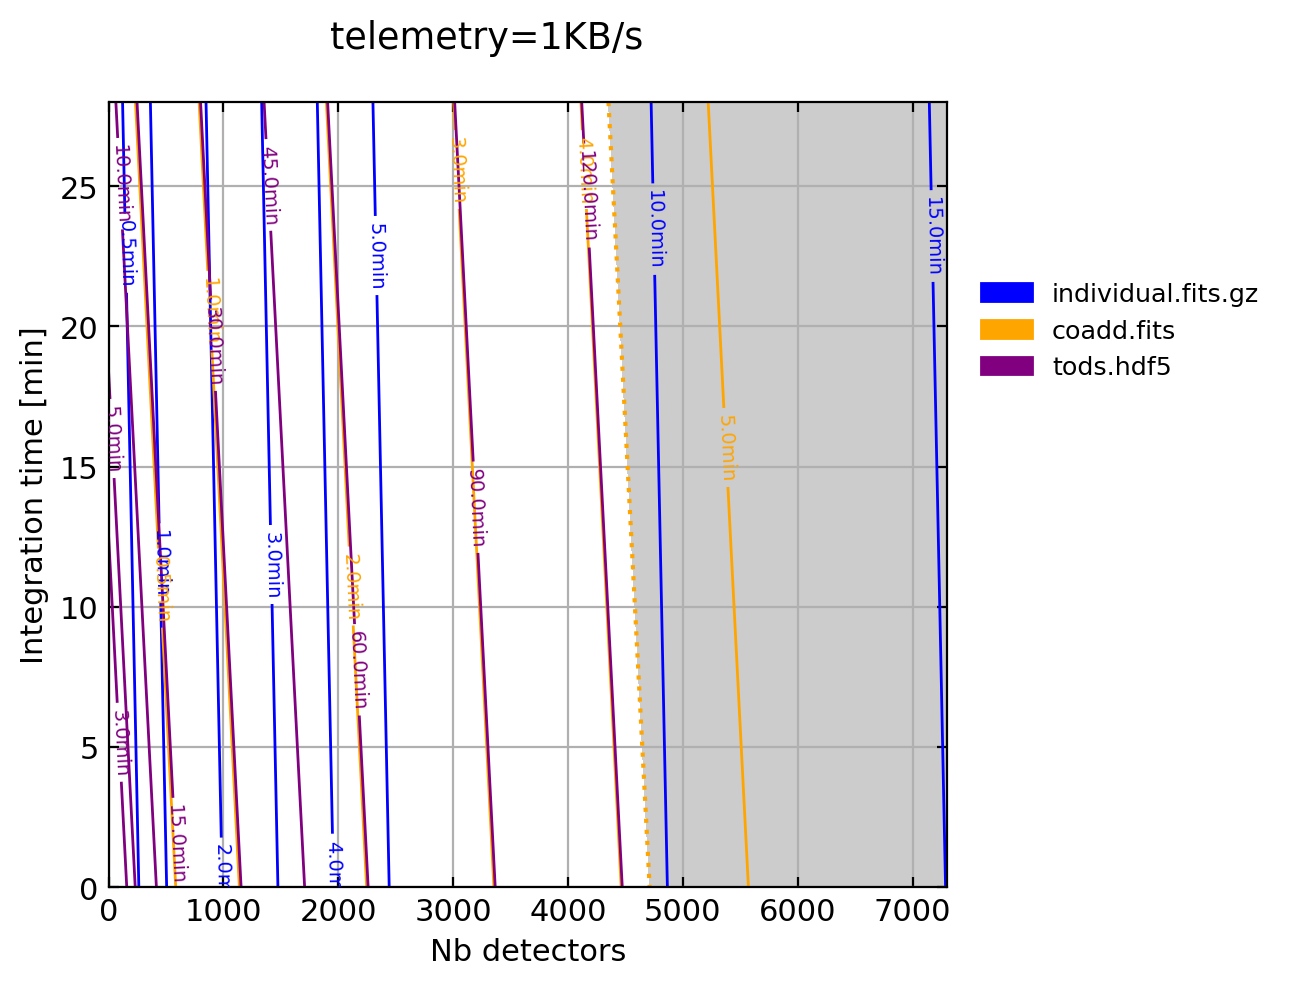

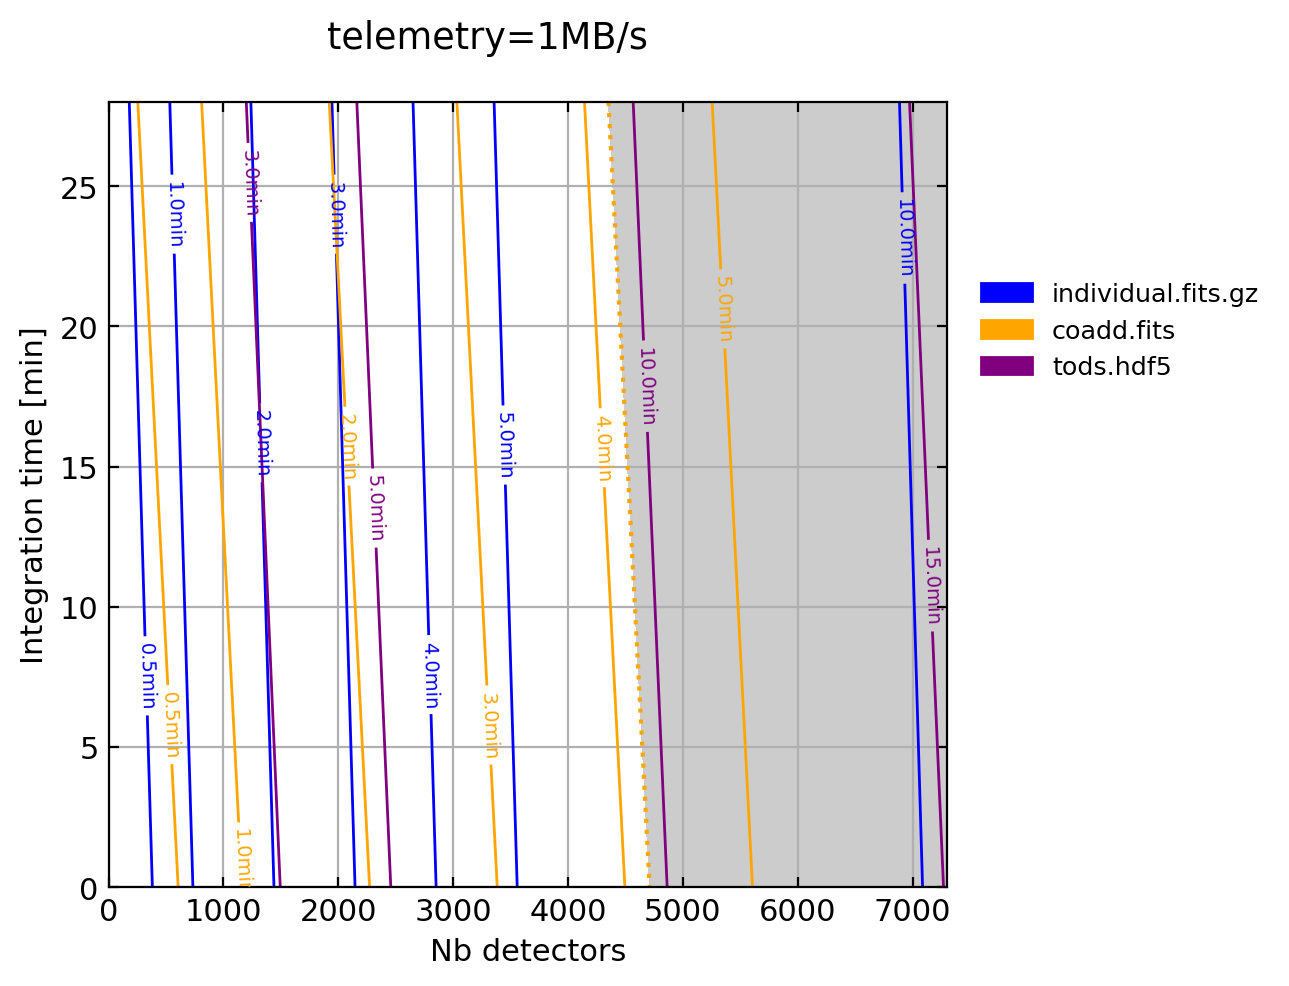

In [35]:

for t,  (telemetry, marker, label) in enumerate(zip((0.048828125,1 ), ('.','x'), ('1KB/s', '1MB/s'), )):

    FIG, AX = plt.subplots(figsize=(5,5), dpi=200)
    FIG.suptitle(f'telemetry={label}')

    patchs = []
    for file, map_compression, ct in zip(files, compressions,('b', 'orange','purple')):

        perfs = pickle.load( open(file, 'rb'))

        norm = cm.colors.Normalize(vmax=1.1, vmin=0)
        cmap = cm.binary
        cset1 = AX.contourf(perfs['% RAM map'], levels=[70,500], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
        cset2 = AX.contour(perfs['% RAM map'], cset1.levels, colors=ct)
        cset2.set_linestyle(':')

        levels = np.asarray((0.5,1,2,3,4,5,10,15,30,45))*60
        if(ct=='purple'):  levels = np.asarray((3,5,10,15,30,45,60,90,120))*60

        CS = AX.contour(perfs[label]['Ttot map'],
                        levels=levels, colors=ct, linewidths=1.0,linestyle = ':',)
        AX.clabel(CS, inline=True, fmt=lambda v: f"{v/60:.1f}min", fontsize=7, colors=ct)
        AX.set_ylabel("Integration time [min]")
        AX.set_xlabel("Nb detectors")

        patch = mpatches.Patch(color=ct, label=map_compression); patchs.append(patch); 

    FIG.tight_layout()
    AX.legend(handles=patchs, bbox_to_anchor = (1.4, 0.8))    

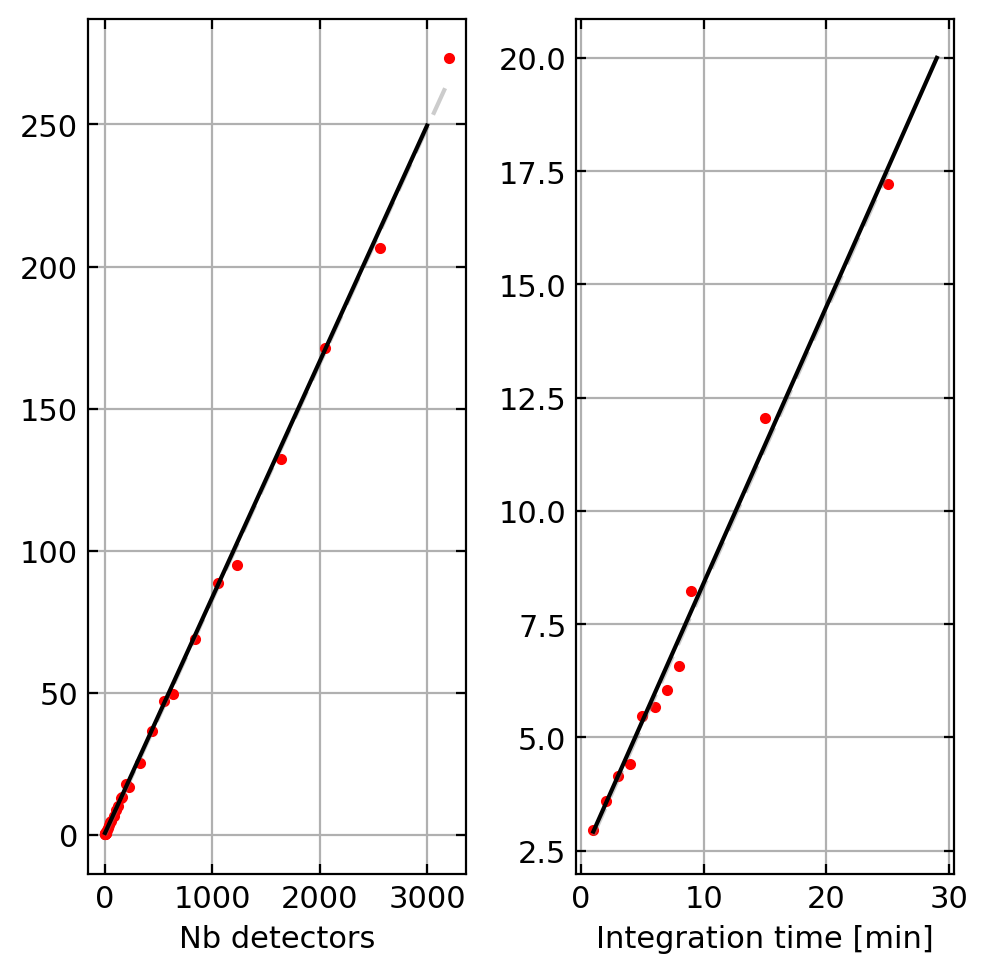

In [12]:
files = ('fits_and_hdf5/namap_perf_profiling_individual_maps.p',  ) #'fits_and_hdf5/namap_perf_profiling_coadded_maps.p',
compressions = ('individual.fits.gz', 'coadd.fits', )

perfs = pickle.load( open(file, 'rb'))
fig, axs = plt.subplots(1,2,figsize=(5,5), dpi=200)

list_linear_params_texe = np.zeros((2,2)) #band ttot texe, precision, a and b

for i, (key, key2) in enumerate(zip(('profiling vs nb bands','profiling vs tod time'),( "nb dets","t_int")) ):

    axt = axs[i]
    axs[0].set_xlabel("Nb detectors")
    axs[1].set_xlabel("Integration time [min]")

    if('det' in key2): lim=3000
    else: lim=30

    precision = 'float32'; p=0; color = 'r'

    #-----------------------------------------------------------------------------------------------------------------------
    axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], f'.{color}')
    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
    list_linear_params_texe[i,0], list_linear_params_texe[i,1] = a_coeffs
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
    #------------------------------------------------------------------------------------------------------------------------

# unpack parameters
a_tint = list_linear_params_texe[1,0]
b_tint = list_linear_params_texe[1,1]
a_band = list_linear_params_texe[0,0]
b_band = list_linear_params_texe[0,1]

# determine the constant C
C = b_tint - a_band * N0

# build the 2D model
Texe_grid = a_tint * T_grid + a_band * N_grid + C

# plot 1D slices
axs[1].plot(y, Texe_grid[:, N0], '-k', markersize=1)
axs[0].plot(x[:3000], Texe_grid[T0, :3000], '-k', markersize=1)


fig.tight_layout()
fig.subplots_adjust(hspace=0)
if(False):
    import matplotlib.cm as cm
    colors = cm.rainbow(np.linspace(0,1,len(x[:3000])))
    for k, cl in enumerate(colors):
        axs[2, 1].plot(y, Texe_grid[:,k],color=cl, alpha=0.01)

    colors = cm.rainbow(np.linspace(0,1,len(y)))
    for k, cl in enumerate(colors):
        axs[2,0].plot(x[:3000], Texe_grid[k,:3000],color=cl, alpha=0.1)
            
                
    figmaps.tight_layout()

    